# Q1 Titanic Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df = df.drop(columns=["PassengerId", "Name", "Age", "Ticket", "Fare"])

df.head()

,Survived,Pclass,Sex,SibSp,Parch,Cabin,Embarked
0,0,3,male,1,0,NaN,S
1,1,1,female,1,0,C85,C
2,1,3,female,0,0,NaN,S
3,1,1,female,1,0,C123,S
4,0,3,male,0,0,NaN,S


In [6]:
# Fill missing categorical values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin has many missing values, so remove it
df = df.drop(columns=["Cabin"])

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
SibSp       0
Parch       0
Embarked    0
dtype: int64


In [7]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

df.head()

,Survived,Pclass,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S
0,0,3,1,0,True,False,True
1,1,1,1,0,False,False,False
2,1,3,0,0,False,False,True
3,1,1,1,0,False,False,True
4,0,3,0,0,True,False,True


In [8]:
correlation = df.corr()

print(correlation)

            Survived    Pclass     SibSp     Parch  Sex_male  Embarked_Q  \
Survived    1.000000 -0.338481 -0.035322  0.081629 -0.543351    0.003650   
Pclass     -0.338481  1.000000  0.083081  0.018443  0.131900    0.221009   
SibSp      -0.035322  0.083081  1.000000  0.414838 -0.114631   -0.026354   
Parch       0.081629  0.018443  0.414838  1.000000 -0.245489   -0.081228   
Sex_male   -0.543351  0.131900 -0.114631 -0.245489  1.000000   -0.074115   
Embarked_Q  0.003650  0.221009 -0.026354 -0.081228 -0.074115    1.000000   
Embarked_S -0.149683  0.074053  0.068734  0.060814  0.119224   -0.499421   

            Embarked_S  
Survived     -0.149683  
Pclass        0.074053  
SibSp         0.068734  
Parch         0.060814  
Sex_male      0.119224  
Embarked_Q   -0.499421  
Embarked_S    1.000000  


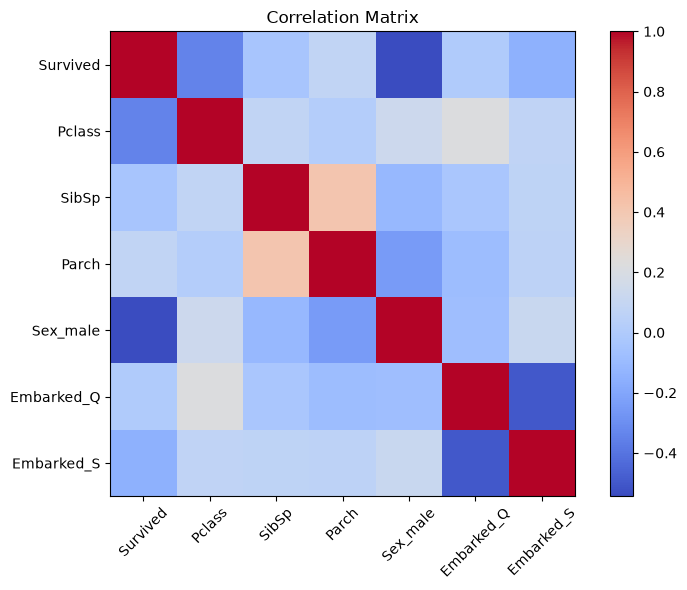

In [9]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [10]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print("Independent variables:")
print(X.head())

print("\nDependent variable:")
print(y.head())

Independent variables:
   Pclass  SibSp  Parch  Sex_male  Embarked_Q  Embarked_S
0       3      1      0      True       False        True
1       1      1      0     False       False       False
2       3      0      0     False       False        True
3       1      1      0     False       False        True
4       3      0      0      True       False        True

Dependent variable:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [13]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1
 0 1 0 0 0 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 1 1 1]


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Logistic Regression Accuracy: 0.770949720670391
Accuracy percentage: 77.09497206703911 %


# Q2 Student Internship Selection

In [15]:
df = pd.read_csv("logistic_regression_student_selection.csv")

df.head()

,Student_ID,Aptitude_Score,Technical_Score,Coding_Score,Selected
0,S001,71,46,67,0
1,S002,63,59,70,0
2,S003,73,60,77,1
3,S004,83,54,77,1
4,S005,62,62,43,0


In [16]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
print(df.info())

Dataset shape: (100, 5)

Missing values:
Student_ID         0
Aptitude_Score     0
Technical_Score    0
Coding_Score       0
Selected           0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Student_ID       100 non-null    str  
 1   Aptitude_Score   100 non-null    int64
 2   Technical_Score  100 non-null    int64
 3   Coding_Score     100 non-null    int64
 4   Selected         100 non-null    int64
dtypes: int64(4), str(1)
memory usage: 4.0 KB
None


In [17]:
X = df[["Aptitude_Score", "Technical_Score", "Coding_Score"]]
y = df["Selected"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Aptitude_Score  Technical_Score  Coding_Score
0              71               46            67
1              63               59            70
2              73               60            77
3              83               54            77
4              62               62            43

Target:
0    0
1    0
2    1
3    1
4    0
Name: Selected, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Test size = 20%")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Test size = 20%
Training samples: 80
Testing samples: 20


In [20]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [21]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0
5,0,1
6,1,1
7,0,1
8,0,0
9,0,0


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9
Accuracy percentage: 90.0 %


In [23]:
probabilities = model.predict_proba(X_test)

probability_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Not_Selected": probabilities[:, 0],
    "Probability_Selected": probabilities[:, 1]
})

probability_results

,Actual,Predicted,Probability_Not_Selected,Probability_Selected
0,0,0,0.824215,0.175785
1,1,1,0.078981,0.921019
2,1,1,0.126381,0.873619
3,1,1,0.499384,0.500616
4,0,0,0.910533,0.089467
5,0,1,0.349964,0.650036
6,1,1,0.057679,0.942321
7,0,1,0.278245,0.721755
8,0,0,0.704509,0.295491
9,0,0,0.538627,0.461373


In [24]:
new_student = pd.DataFrame({
    "Aptitude_Score": [67],
    "Technical_Score": [63],
    "Coding_Score": [60]
})

prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

print("Predicted class:", prediction[0])
print("Probability of not selected:", probability[0][0])
print("Probability of selected:", probability[0][1])

Predicted class: 1
Probability of not selected: 0.4824730862614439
Probability of selected: 0.5175269137385561


In [26]:
if prediction[0] == 1:
    print("The student is predicted to be SELECTED.")
else:
    print("The student is predicted to be NOT SELECTED.")

# print(f"Probability of selection: {probability[0][1]:.4f}")
print(f"Probability of selection: {probability[0][1] * 100:.2f}%")

The student is predicted to be SELECTED.
Probability of selection: 51.75%


# Q3 Social Network Ads

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
df = pd.read_csv("Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [29]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (400, 5)

Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [31]:
numeric_columns = df.select_dtypes(include=["number"]).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [33]:
df = df[["Age", "EstimatedSalary", "Purchased"]]

df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [34]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

print("Independent variables:")
print(X.head())

print("\nDependent variable:")
print(y.head())

Independent variables:
   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000

Dependent variable:
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (320, 2)
Testing data: (80, 2)


In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 0 1 1 0 0]


In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Logistic Regression Accuracy: 0.8625
Accuracy percentage: 86.25 %


# Q4 Loan Approval Based on Annual Income

In [41]:
data = {
    "Annual_Income": [
        200000,
        250000,
        300000,
        350000,
        400000,
        450000,
        500000,
        600000
    ],
    "Loan_Status": [
        "Rejected",
        "Rejected",
        "Rejected",
        "Rejected",
        "Approved",
        "Approved",
        "Approved",
        "Approved"
    ]
}

df = pd.DataFrame(data)

df

,Annual_Income,Loan_Status
0,200000,Rejected
1,250000,Rejected
2,300000,Rejected
3,350000,Rejected
4,400000,Approved
5,450000,Approved
6,500000,Approved
7,600000,Approved


In [42]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Rejected": 0,
    "Approved": 1
})

df

,Annual_Income,Loan_Status
0,200000,0
1,250000,0
2,300000,0
3,350000,0
4,400000,1
5,450000,1
6,500000,1
7,600000,1


In [43]:
X = df[["Annual_Income"]]
y = df["Loan_Status"]

print("X:")
print(X)

print("\ny:")
print(y)

X:
   Annual_Income
0         200000
1         250000
2         300000
3         350000
4         400000
5         450000
6         500000
7         600000

y:
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
Name: Loan_Status, dtype: int64


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6
Testing samples: 2


In [45]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [46]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Annual_Income": X_test["Annual_Income"].values,
    "Actual_Status": y_test.values,
    "Predicted_Status": y_pred
})

results

,Annual_Income,Actual_Status,Predicted_Status
0,300000,0,0
1,500000,1,1


In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Logistic Regression Accuracy: 1.0
Accuracy percentage: 100.0 %


In [48]:
new_customer = pd.DataFrame({
    "Annual_Income": [425000]
})

prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print("Predicted class:", prediction[0])
print("Probability of Rejected:", probability[0][0])
print("Probability of Approved:", probability[0][1])

Predicted class: 1
Probability of Rejected: 6.661338147750939e-16
Probability of Approved: 0.9999999999999993


In [49]:
if prediction[0] == 1:
    print("Loan Status: APPROVED")
else:
    print("Loan Status: REJECTED")

print(f"Probability of approval: {probability[0][1] * 100:.2f}%")

Loan Status: APPROVED
Probability of approval: 100.00%
